In [1]:
import time
import torch
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import numpy as np
%matplotlib inline

## Load the MNIST dataset
Each MNIST image is originally a vector of 784 integers, each of which is between 0-255 and represents the intensity of a pixel. Model each pixel with a Bernoulli distribution in our model, and statically binarize the dataset.

Use tf.data to batch and shuffle the data

In [2]:
data_root = "/p/project1/training2603/course-material"  # where torchvision will store/download files

train_raw = datasets.MNIST(root=data_root, train=True, download=True)
test_raw  = datasets.MNIST(root=data_root, train=False, download=True)

def preprocess_images_np(images_uint8: np.ndarray) -> np.ndarray:
    # TF: images.reshape((N, 28, 28, 1)) / 255.
    images = images_uint8.reshape((images_uint8.shape[0], 28, 28, 1)).astype(np.float32) / 255.0
    # TF: np.where(images > .5, 1.0, 0.0).astype('float32')
    images = np.where(images > 0.5, 1.0, 0.0).astype(np.float32)
    return images

# Convert torchvision (PIL) -> numpy uint8 arrays
train_images_uint8 = np.stack([np.array(img, dtype=np.uint8) for img, _ in train_raw], axis=0)  # [60000,28,28]
test_images_uint8  = np.stack([np.array(img, dtype=np.uint8) for img, _ in test_raw], axis=0)   # [10000,28,28]

train_images = preprocess_images_np(train_images_uint8)  # [N,28,28,1] float32 in {0,1}
test_images  = preprocess_images_np(test_images_uint8)

# ----------------------------
# Dataset + DataLoader (like tf.data)
# ----------------------------
class TensorOnlyDataset(Dataset):
    def __init__(self, x: np.ndarray):
        # PyTorch convention is [N, C, H, W], so transpose from NHWC -> NCHW
        x_t = torch.from_numpy(x).permute(0, 3, 1, 2).contiguous()  # [N,1,28,28]
        self.x = x_t

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx]

train_size = 60000
test_size = 10000
batch_size = 32

train_dataset = TensorOnlyDataset(train_images)
test_dataset = TensorOnlyDataset(test_images)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, drop_last=False)


## Define the encoder and decoder networks

In this VAE example, use two ConvNets for the encoder and decoder networks. In the literature, these networks are also referred to as inference/recognition and generative models respectively. Use `tf.keras.Sequential` to simplify implementation. Let $x$ and $z$ denote the observation and latent variable respectively in the following descriptions.

### Encoder network
This defines the approximate posterior distribution $q(z|x)$, which takes as input an observation and outputs a set of parameters for specifying the conditional distribution of the latent representation $z$. 
In this example, simply model the distribution as a diagonal Gaussian, and the network outputs the mean and log-variance parameters of a factorized Gaussian. 
Output log-variance instead of the variance directly for numerical stability.

### Decoder network 
This defines the conditional distribution of the observation $p(x|z)$, which takes a latent sample $z$ as input and outputs the parameters for a conditional distribution of the observation.
Model the latent distribution prior $p(z)$ as a unit Gaussian.

### Reparameterization trick
To generate a sample $z$ for the decoder during training, you can sample from the latent distribution defined by the parameters outputted by the encoder, given an input observation $x$.
However, this sampling operation creates a bottleneck because backpropagation cannot flow through a random node.

To address this, use a reparameterization trick.
In our example, you approximate $z$ using the decoder parameters and another parameter $\epsilon$ as follows:

$$z = \mu + \sigma \odot \epsilon$$

where $\mu$ and $\sigma$ represent the mean and standard deviation of a Gaussian distribution respectively. They can be derived from the decoder output. The $\epsilon$ can be thought of as a random noise used to maintain stochasticity of $z$. Generate $\epsilon$ from a standard normal distribution.

The latent variable $z$ is now generated by a function of $\mu$, $\sigma$ and $\epsilon$, which would enable the model to backpropagate gradients in the encoder through $\mu$ and $\sigma$ respectively, while maintaining stochasticity through $\epsilon$.

### Network architecture
In the encoder network there are a total of four Conv blocks each consisting of a `Conv2D`, `BatchNorm` and `LeakyReLU` activation function. In each block, the image is downsampled by a factor of two. The slope of `LeakyReLU` is by default 0.2.

In the final block or the Flatten layer we convert the `[None, 7, 7, 64]` to a vector of size 3136.

The decoder network of the variational autoencoder is exactly similar to a vanilla autoencoder. It takes an input of size `[None, 2]`. The initial block has a `Dense` layer having 3136 neurons, recall in the encoder function this was the size of the vector after flattening the output from the last conv block. There are a total of four Conv blocks. The Conv block `[1, 3]` consists of a `Conv2DTranspose`, `BatchNorm` and `LeakyReLU` activation function. The Conv block 4 has a `Conv2DTranspose` with sigmoid activation function, which squashes the output in the range `[0, 1]` since the images are normalized in that range. In each block, the image is upsampled by a factor of two.

The output from the decoder network is a tensor of size `[None, 28, 28, 1]`.
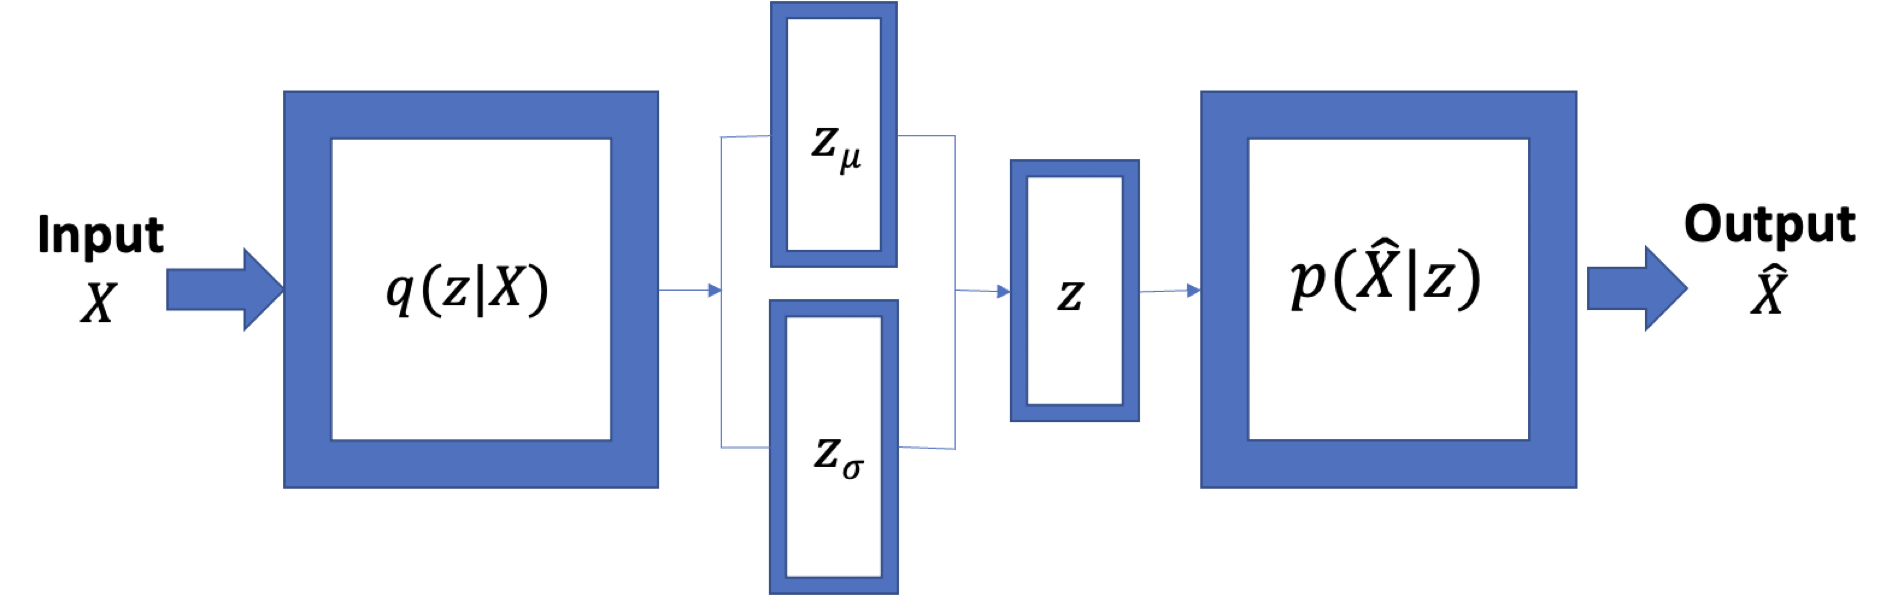

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: input [B,1,28,28] -> output [B, 2*latent_dim]
        self.encoder = nn.Sequential(
            # Block-1
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(inplace=True),

            # Block-2
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),

            # Block-3
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),

            # Block-4
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),

            # Flatten + Dense
            nn.Flatten(),                 # [B, 7*7*64] = [B,3136]
            nn.Linear(3136, 2 * latent_dim)
        )

        # Decoder: input [B,latent_dim] -> output [B,1,28,28] (logits or probs)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 3136),
            nn.Unflatten(dim=1, unflattened_size=(64, 7, 7)),  # [B,64,7,7]

            # Block-1
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),

            # Block-2
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(inplace=True),

            # Block-3
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(inplace=True),

            # Block-4 (TF has sigmoid activation here)
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
        )

    @torch.no_grad()
    def sample(self, eps=None, n: int = 100, device=None):
        if eps is None:
            device = device if device is not None else next(self.parameters()).device
            eps = torch.randn(n, self.latent_dim, device=device)
        return self.decode(eps, apply_sigmoid=True)

    def encode(self, x):
        h = self.encoder(x)  # [B, 2*latent_dim]
        mean, logvar = torch.chunk(h, chunks=2, dim=1)  # each [B, latent_dim]
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = torch.randn_like(mean)
        return eps * torch.exp(0.5 * logvar) + mean

    def decode(self, z, apply_sigmoid: bool = False):
        logits = self.decoder(z)  # [B,1,28,28]
        if apply_sigmoid:
            return torch.sigmoid(logits)
        return logits

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterize(mean, logvar)
        recon = self.decode(z, apply_sigmoid=False)
        return recon, mean, logvar

### Objective Function of VAE

VAE’s loss function comprises a Reconstruction error, and a $KL$-divergence error used to model the networks’ objectives. The final loss is a weighted sum of both losses.

VAE’s total loss can be given as:

$L=(reconstruction\ loss)+(regularization\ term)$

$L=\frac1N\sum_{i=1}^N(X_i-\hat{X}_i)^2+KL(q(z|X)||N(0,1))$, where $X_i$s are input images, $\hat{X}_i$ are the reconstructed images

$KL(q(z|X)||N(0,1))=-\frac12\sum(1+\log z^2_{\sigma_i}-z^2_{\mu_i}-z^2_{\sigma_i})$

### Training

* Start by iterating over the dataset
* During each iteration, pass the image to the encoder to obtain a set of mean and log-variance parameters of the approximate posterior $q(z|x)$
* then apply the *reparameterization trick* to sample from $q(z|x)$
* Finally, pass the reparameterized samples to the decoder to obtain the logits of the generative distribution $p(x|z)$


### Generating images

* After training, it is time to generate some images
* Start by sampling a set of latent vectors from the unit Gaussian prior distribution $p(z)$
* The generator will then convert the latent sample $z$ to logits of the observation, giving a distribution $p(x|z)$


In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


def mse_loss(y_true, y_pred):
    # TF: mean over [1,2,3] -> per-sample scalar
    r_loss = torch.mean((y_true - y_pred) ** 2, dim=(1, 2, 3))  # [B]
    return 1000.0 * r_loss

def kl_loss(mean, log_var):
    # TF: -0.5 * sum(1 + log_var - mean^2 - exp(log_var), axis=1)
    kl = -0.5 * torch.sum(1.0 + log_var - mean**2 - torch.exp(log_var), dim=1)  # [B]
    return kl

def vae_loss(y_true, y_pred, mean, log_var):
    r = mse_loss(y_true, y_pred)          # [B]
    k = kl_loss(mean, log_var)            # [B]
    return r + k                          # [B]

def compute_loss(model, images):
    mean, log_var = model.encode(images)
    z = model.reparameterize(mean, log_var)

    # Match your TF: generated_images = model.decoder(latent)
    # Note: in my CVAE, decoder returns logits (last layer has no sigmoid).
    # Your TF decoder had sigmoid at the end. If you want to match that behavior,
    # apply sigmoid here:
    generated_images = torch.sigmoid(model.decoder(z))

    loss_per_sample = vae_loss(images, generated_images, mean, log_var)  # [B]
    return torch.mean(loss_per_sample)

@torch.no_grad()
def generate_and_save_images(model, epoch, test_sample, fname_tmpl="image_at_epoch_{:04d}.png"):
    model.eval()

    mean, logvar = model.encode(test_sample)
    z = model.reparameterize(mean, logvar)

    # TF: predictions = model.sample(z)
    # In my CVAE: sample(eps=...) decodes and applies sigmoid when apply_sigmoid=True.
    predictions = model.sample(eps=z)  # expected [B,1,28,28]

    # Show a 4x4 grid (first 16)
    n_show = min(predictions.shape[0], 16)
    fig = plt.figure(figsize=(4, 4))

    for i in range(n_show):
        plt.subplot(4, 4, i + 1)
        # NCHW -> HWC for imshow
        img = predictions[i, 0].detach().cpu().numpy()
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(fname_tmpl.format(epoch))
    plt.show()

In the training loop we first pass the image to the encoder, then the latent variables mean and variance are fed to the sampling model and the output latent is finally fed to the decoder. The loss is computed over the images generated by the decoder.

Next, we compute the gradients and update the encoder & decoder parameters using the Adam optimizer. Finally, we return the loss.

In [7]:
import torch

def train_step(images, model, optimizer):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    loss = compute_loss(model, images)   # scalar tensor

    loss.backward()
    optimizer.step()

    return loss

Finally, we train our Autoencoder model. The train function below takes the train_dataset, epochs,model, optimizer and test_sample as the parameters and calls the train_step function at every new batch a number of times.

At every epoch it displays a generated image from the last training epoch using the test sample defined beforehand

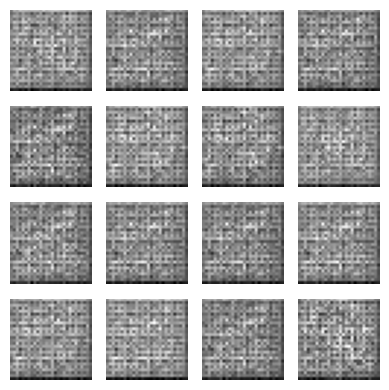

In [ ]:
import time
import torch

def train(train_loader, epochs, model, optimizer, test_sample, device=None):
    device = device if device is not None else next(model.parameters()).device
    test_sample = test_sample.to(device)

    generate_and_save_images(model, 0, test_sample)

    for epoch in range(epochs):
        start = time.time()
        last_loss = None

        for image_batch in train_loader:
            image_batch = image_batch.to(device)
            last_loss = train_step(image_batch, model, optimizer)

        print(f"{last_loss.item():.6f} loss")
        print(f"Time for epoch {epoch + 1} is {time.time() - start:.2f} sec")

        generate_and_save_images(model, epoch + 1, test_sample)


# ---- Get test_sample (first batch, first 16 images) ----
num_examples_to_generate = 16
assert batch_size >= num_examples_to_generate

test_batch = next(iter(test_loader))  # batch of images [B,1,28,28]
test_sample = test_batch[:num_examples_to_generate]

# ---- Build model + optimizer ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# ---- Train ----
train(train_loader, epochs=30, model=model, optimizer=optimizer, test_sample=test_sample, device=device)

# ---- Final generate ----
generate_and_save_images(model, 0, test_sample.to(device))